# 2.2 Stations, but now with relocations

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from types import SimpleNamespace

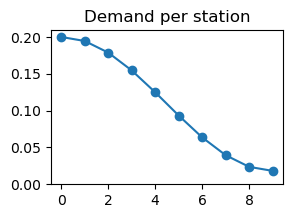

In [212]:
def get_config(scenario, **kwargs):
    """Return a config of values as a SimpleNamespace."""
    d = {}
    if scenario == 'stations':        
        d['n_stations'] = 5                
        d['n_cars'] = 20        
    elif scenario == 'suburbs':
        d['n_stations'] = 10
        d['n_cars'] = 10        
    else:
        raise ValueError("Unknown scenario!")
    d['relo_period'] = 50            
    
    d['n_steps_preparation'] = 30000 # For how many steps stats are NOT collected
    d['n_steps_per_experiment'] = 2000
    d['n_experiments'] = 100
    
    out = SimpleNamespace(**d)

    # Now set any manual corrections, if any
    for key, value in kwargs.items():
        setattr(out, key, value)

    # Calculate demand
    if scenario == 'stations':                
        out.demand = np.arange(out.n_stations, 0, -1)
    elif scenario == 'suburbs':                 
        # out.demand = np.array([1/(1+i) for i in range(out.n_stations)])  # Drop-off    
        out.demand = np.array([np.cos(i/(out.n_stations-1)*np.pi) + 1.2 for i in range(out.n_stations)])  # Hat
    
    out.demand = out.demand / out.demand.max() * 0.2  # For a Poisson approximation to be true, we need to keep this low enough
    # Note that the actual p values don't matter for CM2 calculations, as we set the CM1 coefficient manually anyways (below)
    # The only two things that matter here are that 1) the distribution is correct, 
    # 2) the values are small enough to resemble Poisson process

    # To interpret our data financially,  renormalize them to typical daily values for real cities
    out.cm1_factor = 20*5/max(out.demand) # Assume 20 trips/day from the hottest zone, and 5 €/trip CM1
    out.cm2_factor = 20        
    return out
       
# Practical test
cfg = get_config('suburbs')

plt.figure(figsize=(3, 2)) # Visualize demand, to be sure
plt.plot(cfg.demand, 'o-')
plt.ylim(0, None)
plt.title("Demand per station");

In [166]:
# Main loop

def run_model(cfg):
    np.random.seed(1)
    n_steps = cfg.n_steps_preparation + cfg.n_steps_per_experiment*cfg.n_experiments

    # Make copies of some variables for brevity reasons only
    n_stations = cfg.n_stations
    demand = cfg.demand
    
    cm1 = np.zeros(shape=(cfg.n_experiments, n_stations))
    average_cars = np.zeros(shape=(cfg.n_experiments, n_stations))
    total_attempts = np.zeros(shape=(cfg.n_experiments, n_stations))
    total_rentals = np.zeros(shape=(cfg.n_experiments, n_stations))
    total_relos = np.zeros(shape=(cfg.n_experiments, n_stations))

    # "state" is a simple vector listing the number of cars at each station. 
    # In this model we don't really trace individual cars (yet).
    
    #state = np.array([n_cars // n_stations]*n_stations) # Case of cars being distributed uniformly
    state = np.array([cfg.n_cars] + [0]*(n_stations-1)) # Case of all cars injected in the hot tile
    state[0] = cfg.n_cars - state[1:].sum() # Make sure the total n_cars is right (fix rounding errors, if any)
    state_history = np.zeros(shape=(cfg.n_steps_per_experiment, n_stations)) # Will only remember one run

    for i_step in range(n_steps):
        attempts = (np.random.uniform(size=cfg.n_stations) < demand) # If a car was ordered
        departures = attempts * (state > 0)
        destinations = np.random.choice(
            n_stations, size=n_stations, p=demand/sum(demand)) # Where a car would go if ordered
        # The formula above assumes that ultimately in and out flows for every station are balanced, so if 
        # few people depart from the station (low demand), it will also be unlikely to become a destination
        # (that's why normalized demand is used as a probability parameter for random.choice)
        
        if (i_step >= cfg.n_steps_preparation) & ((i_step - cfg.n_steps_preparation) % cfg.n_steps_per_experiment == 0):
            i_experiment = (i_step - cfg.n_steps_preparation) // cfg.n_steps_per_experiment
            print('.', end='') # Experiment counter

        destinations[~departures] = -1 # If the car didn't leave then it doesn't arrive anywhere
        arrivals = [sum(destinations==i) for i in range(n_stations)] # Manual pivot table

        state = state - departures + arrivals

        # Relocations!        
        if (cfg.relo_period != 0) and (i_step % cfg.relo_period == 0): # It's time to relocate
            demand_per_car = demand / state.clip(1, None)
            # Starting point: smallest demand per car, and there's a car in this zone
            start_relo = np.where((demand_per_car == demand_per_car[state>0].min()) & (state > 0))[0][0]
            # Ending point: highest demand per car
            end_relo = np.argmax(demand/(1+state.clip(1, None)))
            state[start_relo] -= 1
            state[end_relo] += 1
            relo_happened = True
        else:
            relo_happened = False

        if i_step > cfg.n_steps_preparation: # Collect stats
            cm1[i_experiment, :] += (departures + arrivals)/2/cfg.n_steps_per_experiment
            # We divide it by 2 for the sum across all cm1 to be true (not double-counted)
            average_cars[i_experiment, :] += state/cfg.n_steps_per_experiment
            total_attempts[i_experiment, :] += attempts*1            
            total_rentals[i_experiment, :] += departures
            if relo_happened:
                total_relos[i_experiment, start_relo] += 1

            if (n_steps - i_step) < cfg.n_steps_per_experiment: # Last run            
                state_history[(i_step - cfg.n_steps_preparation) % cfg.n_steps_per_experiment, :] = state
                
    return SimpleNamespace(
            cm1=cm1, average_cars=average_cars, n_apps=total_attempts, n_rentals=total_rentals, n_relos=total_relos, history=state_history
        )        
    
# Run experiment 1 : Stations

print("Done")

Done


In [185]:
# CM1 and CM2

def flatten_outputs(out, cfg):
    """Flattens outputs in-place."""
    out.flat_demand = out.n_apps.flatten()/cfg.n_steps_per_experiment
    out.flat_dfr = out.n_rentals.flatten()/out.n_apps.flatten().clip(1,None)
    out.flat_cm1 = out.cm1.flatten()*cfg.cm1_factor
    out.flat_cm2 = out.flat_cm1 - out.average_cars.flatten()*cfg.cm2_factor
    return None

def relo_effect_pic(out, cfg, title):    
    plt.figure(figsize=(10.5, 3.5));
    
    plt.subplot(131)
    plt.title(title, loc='left', pad=15)
    plt.plot(out.n_apps.flatten()/cfg.n_steps_per_experiment, 
         out.average_cars.flatten(), '.', alpha=0.1, markersize=10)
    plt.plot(cfg.demand, out.average_cars.mean(axis=0), 'ks-')
    plt.xlabel("Average demand")
    plt.ylabel("Average number of cars");

    plt.subplot(132)    
    plt.plot(out.flat_demand, out.flat_cm1, '.', alpha=0.1, markersize=10)
    plt.plot(out.n_apps.mean(axis=0)/cfg.n_steps_per_experiment, out.cm1.mean(axis=0)*cfg.cm1_factor, 'ks-')
    plt.xlabel("Average demand")
    plt.ylabel("CM1 per day, Eur");
    
    plt.subplot(133)
    plt.axhline(0, color='red', linestyle=':')
    plt.plot(out.flat_demand, out.flat_cm2, '.', alpha=0.1, markersize=10)
    plt.plot(
        out.n_apps.mean(axis=0)/cfg.n_steps_per_experiment, 
        (out.cm1*cfg.cm1_factor - out.average_cars*cfg.cm2_factor).mean(axis=0), 'ks-')
    plt.xlabel("Average demand")
    plt.ylabel("CM2 per day, Eur");
    
    plt.tight_layout()
    print()
    print(f"Average rentals per relo: {out.n_rentals.sum()/max(1, out.n_relos.sum())}")
    print(f"Average CM2/day: {out.flat_cm2.sum()/cfg.n_experiments}")

print("Done")

Done


....................................................................................................
Average rentals per relo: 100189.0
Average CM2/day: -149.52549999999678


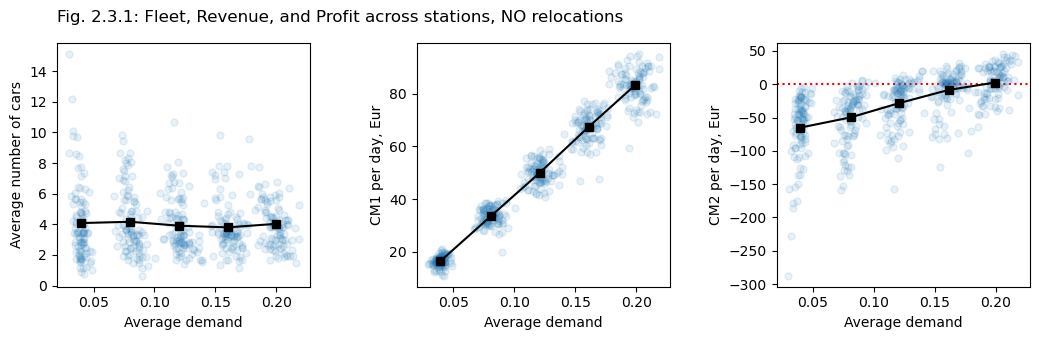

In [202]:
# Sxperiment 1 : Stations, no relos
cfg = get_config('stations', relo_period=1e9)  # 1e9 is basically infinity
out = run_model(cfg)
flatten_outputs(out, cfg)
relo_effect_pic(out, cfg, title="Fig. 2.3.1: Fleet, Revenue, and Profit across stations, NO relocations")
plt.savefig(f"../figures/02relos_03stations_01norelos.svg", dpi=300)

....................................................................................................
Averate rentals per relo: 26.895473868467118
Average CM2/day: -131.11049999999625


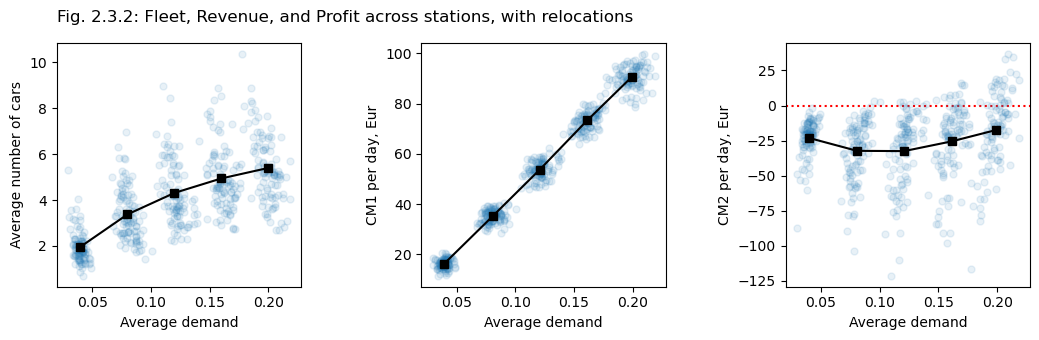

In [168]:
# now with relocations
cfg2 = get_config('stations', relo_period=50)
out2 = run_model(cfg2)
flatten_outputs(out2, cfg2)
relo_effect_pic(out2, cfg2, title="Fig. 2.3.2: Fleet, Revenue, and Profit across stations, with relocations")
plt.savefig(f"../figures/02relos_03stations_02relos.svg", dpi=300)

....................................................................................................
Average rentals per relo: 152883.0
Average CM2/day: -17.790499999993465


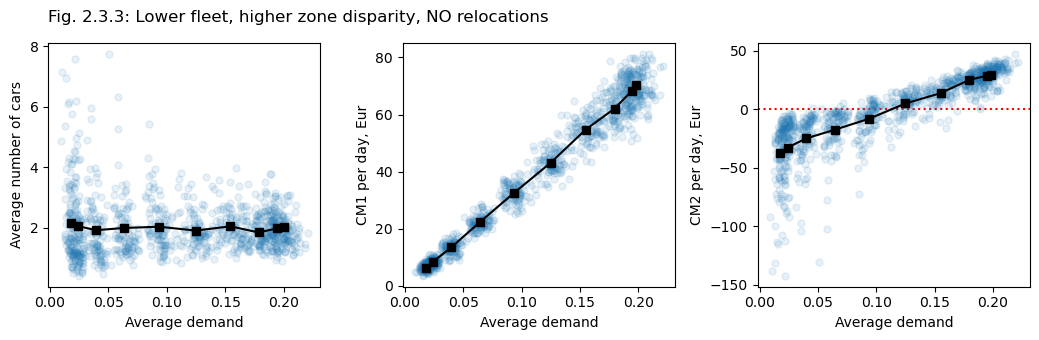

In [215]:
# More realistic configuration, no relocations
cfg3 = get_config('suburbs', n_cars=20, relo_period=1e9)
out3 = run_model(cfg3)
flatten_outputs(out3, cfg3)
relo_effect_pic(out3, cfg3, title="Fig. 2.3.3: Lower fleet, higher zone disparity, NO relocations")
plt.savefig(f"../figures/02relos_03stations_03better_model_no_relos.svg", dpi=300)

....................................................................................................
Average rentals per relo: 41.481620405101275
Average CM2/day: 14.71450000000606


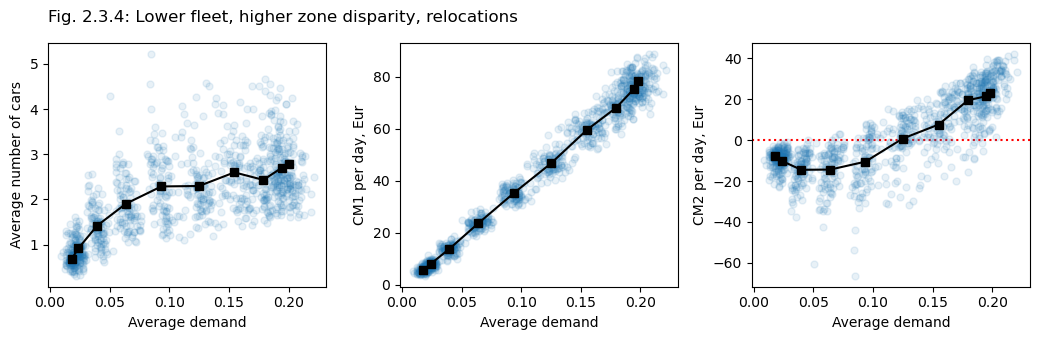

In [216]:
# More realistic configuration, WITH relocations
cfg4 = get_config('suburbs', n_cars=20, relo_period=50)
out4 = run_model(cfg4)
flatten_outputs(out4, cfg4)
relo_effect_pic(out4, cfg4, title="Fig. 2.3.4: Lower fleet, higher zone disparity, relocations")
plt.savefig(f"../figures/02relos_03stations_04better_model.svg", dpi=300)

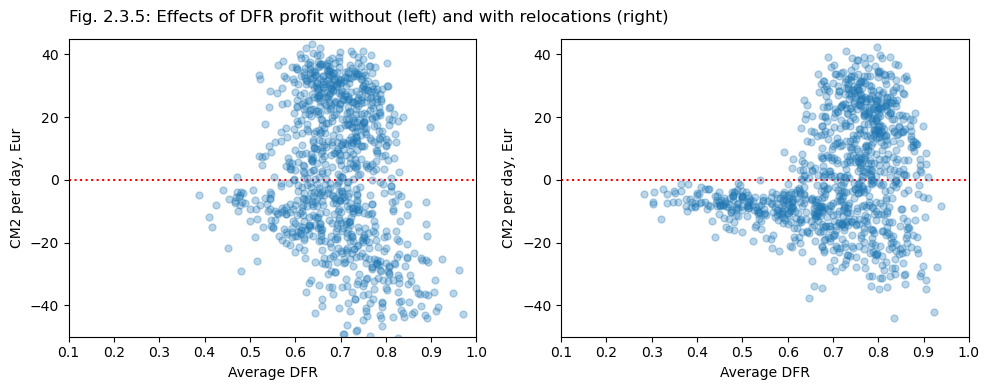

In [217]:
# DFR

plt.figure(figsize=(10,4));
plt.subplot(121)
plt.title("Fig. 2.3.5: Effects of DFR profit without (left) and with relocations (right)", loc='left', pad=12)
plt.axhline(0, color='red', linestyle=':')
plt.plot(out3.flat_dfr, out3.flat_cm2, '.', alpha=0.3, markersize=10)
plt.xlabel("Average DFR")
plt.ylabel("CM2 per day, Eur");
plt.xlim([0.1, 1])
plt.ylim([-50, 45])

plt.subplot(122)
plt.axhline(0, color='red', linestyle=':')
plt.plot(out4.flat_dfr, out4.flat_cm2, '.', alpha=0.3, markersize=10)
plt.xlabel("Average DFR")
plt.ylabel("CM2 per day, Eur");
plt.xlim([0.1, 1])
plt.ylim([-50, 45])

plt.tight_layout()

plt.savefig(f"../figures/02relos_03stations_05dfr.svg", dpi=300)

# Optimal number of relocations

In [13]:
# Optimal number of relocations
# (Make sure to load a correct scenario before running this one)

relo_frequencies = [1, 10, 20, 35, 50, 75, 100, 150, 200]
relocation_periods = [int(n_steps_per_experiment/freq) for freq in relo_frequencies]
print(relocation_periods)

cm1_per_trip = 5
relo_cost = 20
n_experiments = 100

cm1_memory = np.zeros(shape=(n_experiments, len(relocation_periods)))

for i, rpr in enumerate(relocation_periods):
    cm1, average_cars, total_attempts, total_rentals, total_relos, history = \
        run_model(rentals_per_relocation=rpr, n_experiments=n_experiments)    
    
    # Calculate full CM1
    cm1_memory[:, i] = (
        total_rentals.sum(axis=1)/n_steps_per_experiment * cm1_per_trip # Sum accross stations,
        - total_relos.sum(axis=1)/n_steps_per_experiment * relo_cost    # ... but not across experiments
    )
    print() # New line
    
cm1_memory.shape

[2000, 200, 100, 57, 40, 26, 20, 13, 10]
....................................................................................................
....................................................................................................
....................................................................................................
....................................................................................................
....................................................................................................
....................................................................................................
....................................................................................................
....................................................................................................
....................................................................................................


(100, 9)

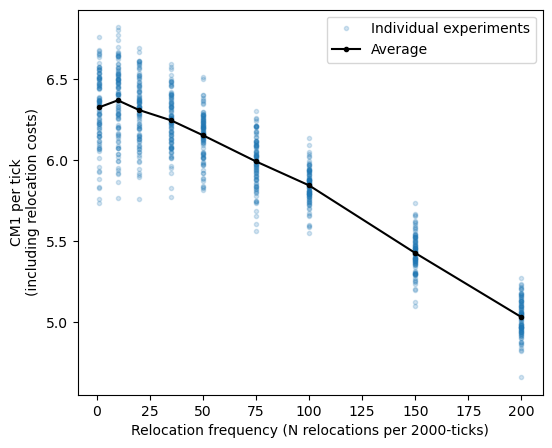

In [15]:
# Save figure
plt.figure(figsize=(6,5))
plt.plot(list(relo_frequencies)*n_experiments, cm1_memory.flatten(), '.', color='tab:blue', alpha=0.2,
         label="Individual experiments");
plt.plot(relo_frequencies, cm1_memory.mean(axis=0), 'k.-', label='Average');
plt.xlabel(f"Relocation frequency (N relocations per {n_steps_per_experiment}-ticks)")
plt.ylabel("CM1 per tick\n(including relocation costs)");
#plt.title(f"Scenario: {scenario}")
plt.legend(loc="upper right")

plt.savefig(f"../figures/02relos_02stations_03optimal_number_{scenario}.svg", dpi=300)